# CSCI E-89: Homework 4

Paul Schwartzberg

## Problem 1: recognise handwritten digits

Adapted from the course notebook `1_pytorch_basic_cnn_digits.ipynb`. We replace scikit-learn's 8 x 8 digit images with MNIST images from torchvision. Each MNIST image has 28 x 28 pixels.

**Progress:** load and inspect the data. Training, evaluation and inference on my own handwriting will follow.

### 1. Set up the environment

Use the `cscie89` kernel. The printed Python path lets us check that the notebook uses the intended environment. A convolutional neural network (CNN) learns image features through filters whose weights change during training.

In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torchvision import datasets, transforms

# Fixed seeds make later splits and model initialisation more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python executable: {sys.executable}")
print(f"PyTorch: {torch.__version__}")
print(f"torchvision: {torchvision.__version__}")
print(f"Device: {device}")

Python executable: C:\Users\schwa\.conda\envs\cscie89\python.exe
PyTorch: 2.14.0+cpu
torchvision: 0.29.0+cpu
Device: cpu


### 2. Load MNIST through torchvision

A `Dataset` provides an image and its label when we request an item. `datasets.MNIST` supplies the images; `ToTensor()` converts them to the format PyTorch needs.

MNIST has 60,000 training images and 10,000 test images. <br>
We will later divide the training pool into training and validation sets. <br> The test set stays separate until final evaluation.

The shape `(1, 28, 28)` means one colour channel, 28 rows and 28 columns. <br>
Labels are integers from 0 to 9. <br> The first run downloads the data; later runs reuse the local files.

In [2]:
# ToTensor converts each greyscale image to a float tensor of shape
# (1, 28, 28) and scales its pixel values from 0-255 to 0-1.
transform = transforms.ToTensor()
DATA_DIR = Path("data")

mnist_train_full = datasets.MNIST(
    root=DATA_DIR, train=True, download=True, transform=transform
)
mnist_test = datasets.MNIST(
    root=DATA_DIR, train=False, download=True, transform=transform
)

# Inspect a training example; keep the test set for final evaluation.
image, label = mnist_train_full[0]
print(f"Training pool: {len(mnist_train_full):,} images")
print(f"Test set: {len(mnist_test):,} images")
print(f"One image: {tuple(image.shape)}")
print(f"Tensor type: {image.dtype}")
print(f"Pixel range in this image: {image.min().item():.1f} to {image.max().item():.1f}")
print(f"Label: {label}")

Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


...

MNIST download completed.


MNIST download completed.


MNIST download completed.


MNIST download completed.


Training pool: 60,000 images
Test set: 10,000 images
One image: (1, 28, 28)
Tensor type: torch.float32
Pixel range in this image: 0.0 to 1.0
Label: 5


### 3. Inspect the images

Show one training example per class to check the labels and appearance.<br>
The digits are bright against a dark background. <br>When we prepare my handwritten digits later, we will match this format.

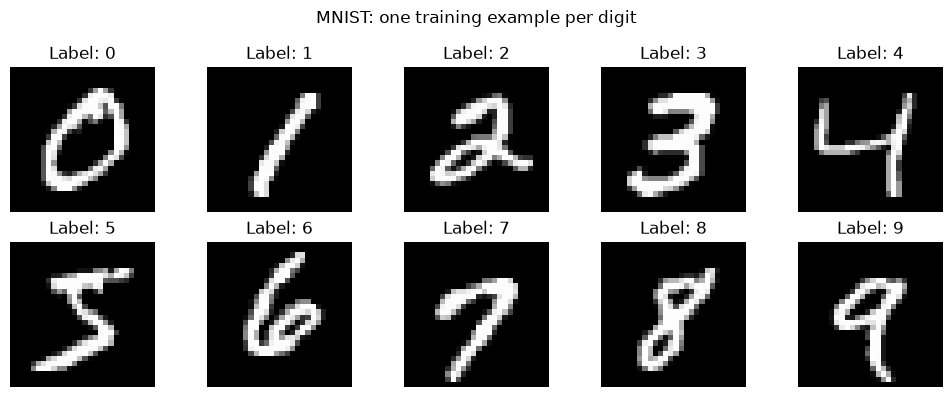

In [3]:
# Show one training image for each digit.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    index = (mnist_train_full.targets == digit).nonzero(as_tuple=True)[0][0].item()
    image, label = mnist_train_full[index]
    ax.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {label}")
    ax.axis("off")
fig.suptitle("MNIST: one training example per digit")
plt.tight_layout()
plt.show()

### Next step

Split the training pool into training and validation sets, then use `DataLoader` objects to serve batches of images to the model.

## Problem 2: improve flower classification

Adapted from `2_pytorch_CNN_Classify_flowers.ipynb`.

The task is to classify photos as daisy, dandelion, roses, sunflowers or tulips. <br>
The course model has three convolutional blocks and two linear layers. <br>We must add two convolutional blocks and one linear layer with ReLU, then document a small set of experiments.<br> We will use no data augmentation.

The supplied notebook records 75.1% training accuracy at its final epoch and 65.34% test accuracy for the checkpoint selected by validation loss. <br>These are different measures; the supplied results are reference results, not results from our own run.

We will keep the same data split across experiments, use validation results to choose settings and check for overfitting, <br>and reserve the test set for final evaluation. Adding depth does not guarantee better accuracy.

**Progress:** the data split and baseline run are complete. <br>The deeper model and experiments will follow.

### 2.1 Load the flower photos

Unlike MNIST, these photos arrive in folders, one per flower class. <br>`ImageFolder` reads the folder names and assigns integer labels in alphabetical order.

`Resize` makes every image 64 x 64 pixels; this can change its proportions. <br>`ToTensor` converts it to a tensor and scales the pixel values to 0-1.<br> `Compose` applies these operations in order. RGB photos have three channels, so each tensor has shape `(3, 64, 64)`.

The first run downloads an archive of about 220 MB into `data/`.<br> Git ignores this folder. We will split this catalogue into training, validation and test sets in the next step.

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive

# Separate names keep the flower data distinct from Problem 1's MNIST data.
FLOWER_DATA_DIR = Path("data")
FLOWER_IMAGE_SIZE = 64
flower_root = FLOWER_DATA_DIR / "flower_photos"

# Reuse the downloaded photos on later runs.
if not flower_root.exists():
    download_and_extract_archive(
        "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
        download_root=str(FLOWER_DATA_DIR),
        md5="6f87fb78e9cc9ab41eff2015b380011d",
    )

# Resize to a common size and convert to tensors. No data augmentation.
flower_transform = transforms.Compose([
    transforms.Resize((FLOWER_IMAGE_SIZE, FLOWER_IMAGE_SIZE)),
    transforms.ToTensor(),
])
flower_catalog = datasets.ImageFolder(flower_root, transform=flower_transform)
flower_class_names = flower_catalog.classes
print(f"Images: {len(flower_catalog):,}")
print(f"Folder-to-label mapping: {flower_catalog.class_to_idx}")
flower_image, flower_label = flower_catalog[0]
print(f"One image: {tuple(flower_image.shape)}")
print(f"Label: {flower_label} ({flower_class_names[flower_label]})")

Images: 3,670
Folder-to-label mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
One image: (3, 64, 64)
Label: 0 (daisy)


### 2.2 Inspect one photo per class

For MNIST, we removed the single channel dimension to plot a greyscale image. Here, all three colour channels are needed. `permute(1, 2, 0)` moves the channel dimension to the end, changing `(3, 64, 64)` into `(64, 64, 3)` for Matplotlib. It does not discard colour information.

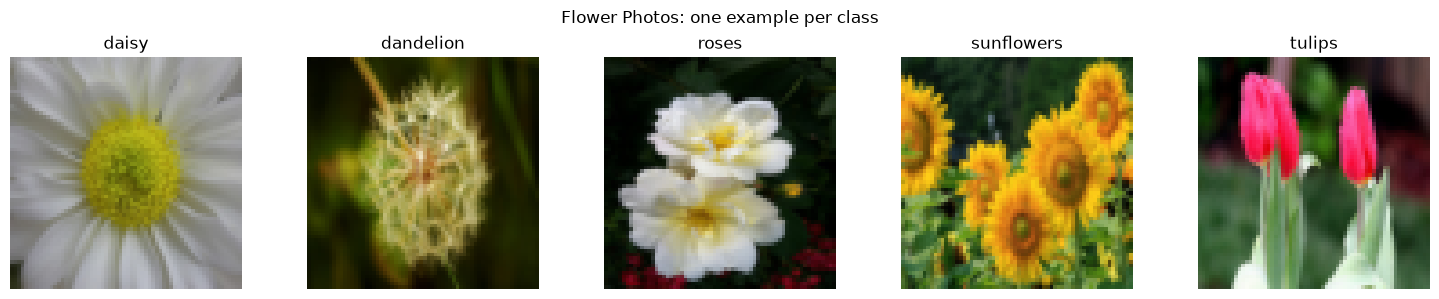

In [5]:
# Show one example per class to check the images and folder labels.
fig, axes = plt.subplots(1, len(flower_class_names), figsize=(15, 3))
for label, ax in enumerate(axes):
    index = flower_catalog.targets.index(label)
    image, target = flower_catalog[index]
    # RGB plotting needs (height, width, channels), rather than (channels, height, width).
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(flower_class_names[target])
    ax.axis("off")
fig.suptitle("Flower Photos: one example per class")
plt.tight_layout()
plt.show()

### 2.3 Split the data

We use 70% of the photos for training, about 15% for validation and about 15% for testing. Whole images cannot be split, so the last two sets differ by one image.

- **Training:** updates the model weights.
- **Validation:** compares experiments and selects the saved weights.
- **Test:** evaluates the final selected model.

`train_test_split` divides image indices. <br>`stratify` keeps approximately the same proportion of each flower class in each set.<br> A fixed `random_state` makes the split repeatable. <br>The second split uses the labels of the remaining images, in their current order.<br>

`Subset` refers to selected examples in the existing catalogue; it does not copy image files.<br> All three subsets therefore use the same resizing and tensor conversion. We will retain this split throughout our experiments.

In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader

FLOWER_SEED = 42
flower_indices = np.arange(len(flower_catalog))
flower_targets = np.asarray(flower_catalog.targets)

# Reserve 30% for validation and testing; use 70% for training.
flower_train_indices, flower_remaining_indices = train_test_split(
    flower_indices,
    test_size=0.30,
    random_state=FLOWER_SEED,
    stratify=flower_targets,
)

# Divide the reserved images equally between validation and testing.
flower_val_indices, flower_test_indices = train_test_split(
    flower_remaining_indices,
    test_size=0.50,
    random_state=FLOWER_SEED,
    stratify=flower_targets[flower_remaining_indices],
)

# Each Subset retrieves only its assigned images from the original catalogue.
flower_train_dataset = Subset(flower_catalog, flower_train_indices.tolist())
flower_val_dataset = Subset(flower_catalog, flower_val_indices.tolist())
flower_test_dataset = Subset(flower_catalog, flower_test_indices.tolist())

# Check that every image belongs to exactly one split.
flower_split_sets = [set(indices.tolist()) for indices in
                     (flower_train_indices, flower_val_indices, flower_test_indices)]
assert flower_split_sets[0].isdisjoint(flower_split_sets[1])
assert flower_split_sets[0].isdisjoint(flower_split_sets[2])
assert flower_split_sets[1].isdisjoint(flower_split_sets[2])
assert set.union(*flower_split_sets) == set(flower_indices.tolist())

for name, indices in [("Training", flower_train_indices),
                      ("Validation", flower_val_indices),
                      ("Test", flower_test_indices)]:
    counts = np.bincount(flower_targets[indices], minlength=len(flower_class_names))
    print(f"{name}: {len(indices):,} images")
    print(dict(zip(flower_class_names, counts.tolist())))

Training: 2,569 images
{'daisy': 443, 'dandelion': 629, 'roses': 449, 'sunflowers': 489, 'tulips': 559}
Validation: 550 images
{'daisy': 95, 'dandelion': 134, 'roses': 96, 'sunflowers': 105, 'tulips': 120}
Test: 551 images
{'daisy': 95, 'dandelion': 135, 'roses': 96, 'sunflowers': 105, 'tulips': 120}


### 2.4 Prepare batches

A `Dataset` supplies individual examples.<br> A `DataLoader` groups them into batches. <br>Here, a full batch contains 64 images and 64 labels. <br>Its image tensor has shape `(64, 3, 64, 64)`: batch size, colour channels, height and width.

We shuffle only the training set. <br>Validation and test examples keep a fixed order. <br>`num_workers=0` loads images in the current process, which keeps this setup straightforward. <br>The final batch may contain fewer than 64 images; the default keeps it.

The seeded generator controls training shuffles. <br>Its state advances as batches are requested.<br> When comparing models later, we will reset the model seed and training-loader generator for each run. <br>The preview below uses a separate loader.

In [7]:
FLOWER_BATCH_SIZE = 64

# Shuffle training examples into a new order on each pass through the data.
flower_train_loader = DataLoader(
    flower_train_dataset,
    batch_size=FLOWER_BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(FLOWER_SEED),
    num_workers=0,
)
flower_val_loader = DataLoader(
    flower_val_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)
flower_test_loader = DataLoader(
    flower_test_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)

# Use a separate loader for this preview so the training shuffle is untouched.
flower_preview_loader = DataLoader(
    flower_train_dataset, batch_size=FLOWER_BATCH_SIZE,
    shuffle=False, num_workers=0,
)
flower_batch_images, flower_batch_labels = next(iter(flower_preview_loader))
print(f"Image batch: {tuple(flower_batch_images.shape)}")
print(f"Label batch: {tuple(flower_batch_labels.shape)}")
print(f"Label type: {flower_batch_labels.dtype}")
print(f"Training batches per epoch: {len(flower_train_loader)}")
assert flower_batch_images.shape == (FLOWER_BATCH_SIZE, 3, FLOWER_IMAGE_SIZE, FLOWER_IMAGE_SIZE)
assert flower_batch_labels.dtype == torch.int64

Image batch: (64, 3, 64, 64)
Label batch: (64,)
Label type: torch.int64
Training batches per epoch: 41


**Next step:** build and train the course model as a baseline. Then add the required layers and compare a small number of experiments using the same validation set.

### 2.5 Build the baseline CNN

A baseline is the starting model against which we compare changes. This is the three-block CNN from the course, with its original layer sizes.

Each block contains a convolution, ReLU and max pooling. A convolution learns filters that respond to image patterns. ReLU replaces negative values with zero. Max pooling keeps the largest value in each 2 x 2 region, halving the height and width. Padding keeps the convolution itself from shrinking the image.

For one image, the shapes after each block are:

`(3, 64, 64) -> (16, 32, 32) -> (32, 16, 16) -> (64, 8, 8)`

`Flatten` turns the last feature maps into 4,096 values per image. A linear layer combines them into 64 values, ReLU follows, and the final linear layer produces five class scores. These scores are called logits. The batch dimension remains throughout.

`CrossEntropyLoss` compares the raw scores with the correct class labels. We do not add softmax to the model because this loss handles the needed conversion internally. Adam uses gradients to update the weights.

Run this cell again before repeating baseline training: it creates fresh weights and a fresh optimiser. The fixed seed helps repeat runs within the same environment; it does not guarantee identical results across devices or software versions.

In [4]:
import copy
import json
import random
import time
from torch import nn

# Match the course baseline: 64 x 64 images, Adam, 0.001 learning rate, 15 epochs.
FLOWER_EPOCHS = 15
FLOWER_LEARNING_RATE = 0.001
flower_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_num_threads(4)
random.seed(FLOWER_SEED)
np.random.seed(FLOWER_SEED)
torch.manual_seed(FLOWER_SEED)

class BaselineFlowerCNN(nn.Module):
    """The course model: three convolutional blocks and two linear layers."""

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (3, 64, 64) -> (16, 32, 32).
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: (16, 32, 32) -> (32, 16, 16).
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: (32, 16, 16) -> (64, 8, 8).
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (FLOWER_IMAGE_SIZE // 8) ** 2, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, images):
        features = self.features(images)
        return self.classifier(features)

flower_baseline = BaselineFlowerCNN(len(flower_class_names)).to(flower_device)
flower_criterion = nn.CrossEntropyLoss()
flower_optimizer = torch.optim.Adam(
    flower_baseline.parameters(), lr=FLOWER_LEARNING_RATE
)

print(f"Device: {flower_device}")
print(flower_baseline)
print(f"Trainable parameters: {sum(p.numel() for p in flower_baseline.parameters()):,}")
with torch.no_grad():
    flower_example_scores = flower_baseline(flower_batch_images.to(flower_device))
print(f"Output shape: {tuple(flower_example_scores.shape)}")
assert flower_example_scores.shape == (len(flower_batch_images), len(flower_class_names))

Device: cpu
BaselineFlowerCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=5, bias=True)
  )
)
Trainable parameters: 286,117
Output shape: (64, 5)


### 2.6 Train and validate the baseline

An epoch is one complete pass through the training set. We use 15 epochs and a learning rate of 0.001, matching the course baseline.

The evaluation function measures loss and accuracy without changing weights. `model.eval()` selects evaluation behaviour; `torch.no_grad()` avoids recording calculations for backpropagation.

For each training batch we clear old gradients, calculate scores, measure loss, calculate gradients and update weights. At the end of each epoch, we evaluate on validation images. Training metrics are accumulated while weights change; validation metrics use the weights at the end of the epoch.

We retain a separate copy of the weights whenever validation loss improves. After all 15 epochs, we restore the best copy. This is checkpoint selection, not early stopping: every epoch still runs. We do not use the test loader here.

In [5]:
def evaluate_flower_model(model, loader):
    """Measure average loss and accuracy without updating model weights."""
    model.eval()
    loss_sum = 0.0
    correct = 0
    count = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(flower_device)
            labels = labels.to(flower_device)
            scores = model(images)
            loss = flower_criterion(scores, labels)
            # Weight each batch by its size; the last batch can be smaller.
            loss_sum += loss.item() * len(labels)
            correct += (scores.argmax(dim=1) == labels).sum().item()
            count += len(labels)
    return loss_sum / count, correct / count

In [6]:
# Recreate the loader so earlier notebook activity does not change its shuffle.
flower_train_loader = DataLoader(
    flower_train_dataset, batch_size=FLOWER_BATCH_SIZE, shuffle=True,
    generator=torch.Generator().manual_seed(FLOWER_SEED), num_workers=0,
)
flower_baseline_history = {
    "train_loss": [], "val_loss": [],
    "train_accuracy": [], "val_accuracy": [],
}
flower_best_val_loss = float("inf")
flower_best_state = None
flower_best_epoch = 0
flower_start_time = time.perf_counter()

for epoch in range(1, FLOWER_EPOCHS + 1):
    flower_baseline.train()
    loss_sum = 0.0
    correct = 0
    count = 0
    for images, labels in flower_train_loader:
        images = images.to(flower_device)
        labels = labels.to(flower_device)
        flower_optimizer.zero_grad()                 # Clear previous gradients.
        scores = flower_baseline(images)             # Calculate class scores.
        loss = flower_criterion(scores, labels)       # Measure prediction error.
        loss.backward()                              # Calculate gradients.
        flower_optimizer.step()                      # Update model weights.
        loss_sum += loss.item() * len(labels)
        correct += (scores.argmax(dim=1) == labels).sum().item()
        count += len(labels)

    train_loss = loss_sum / count
    train_accuracy = correct / count
    val_loss, val_accuracy = evaluate_flower_model(flower_baseline, flower_val_loader)
    flower_baseline_history["train_loss"].append(train_loss)
    flower_baseline_history["train_accuracy"].append(train_accuracy)
    flower_baseline_history["val_loss"].append(val_loss)
    flower_baseline_history["val_accuracy"].append(val_accuracy)

    if val_loss < flower_best_val_loss:
        flower_best_val_loss = val_loss
        flower_best_epoch = epoch
        # Copy the weights so later training does not change this saved state.
        flower_best_state = copy.deepcopy(flower_baseline.state_dict())

    print(f"Epoch {epoch:02d}/{FLOWER_EPOCHS} | "
          f"train loss {train_loss:.3f}, accuracy {train_accuracy:.1%} | "
          f"validation loss {val_loss:.3f}, accuracy {val_accuracy:.1%}", flush=True)

flower_training_seconds = time.perf_counter() - flower_start_time
flower_baseline.load_state_dict(flower_best_state)
flower_baseline.eval()
flower_selected_val_loss, flower_selected_val_accuracy = evaluate_flower_model(
    flower_baseline, flower_val_loader
)
assert abs(flower_selected_val_loss - flower_best_val_loss) < 1e-6
print(f"Restored epoch {flower_best_epoch}, chosen by lowest validation loss.")
print(f"Selected validation accuracy: {flower_selected_val_accuracy:.2%}")
print(f"Training time: {flower_training_seconds / 60:.1f} minutes")

Epoch 01/15 | train loss 1.453, accuracy 33.4% | validation loss 1.277, accuracy 45.6%


Epoch 02/15 | train loss 1.187, accuracy 48.7% | validation loss 1.119, accuracy 54.9%


Epoch 03/15 | train loss 1.088, accuracy 54.3% | validation loss 1.137, accuracy 52.5%


Epoch 04/15 | train loss 1.064, accuracy 56.2% | validation loss 1.022, accuracy 60.4%


Epoch 05/15 | train loss 0.975, accuracy 61.6% | validation loss 0.991, accuracy 60.0%


...

Epoch 12/15 | train loss 0.770, accuracy 69.4% | validation loss 0.977, accuracy 61.6%


Epoch 13/15 | train loss 0.740, accuracy 70.0% | validation loss 0.934, accuracy 63.8%


Epoch 14/15 | train loss 0.707, accuracy 71.3% | validation loss 0.990, accuracy 63.1%


Epoch 15/15 | train loss 0.684, accuracy 73.6% | validation loss 1.038, accuracy 63.8%


Restored epoch 11, chosen by lowest validation loss.
Selected validation accuracy: 64.18%
Training time: 1.6 minutes


### 2.7 Inspect learning curves and save the baseline

Lower loss and higher accuracy indicate improvement. If training improves while validation loss rises, that suggests overfitting. The dashed line marks the epoch selected by validation loss, which need not have the highest validation accuracy.

We save the selected weights, validation results and data split. A reload check verifies that the saved weights reproduce the same scores on a training batch. Test results remain pending until we have compared the planned experiments.

The deeper model required by the assignment will be a separate experiment: five convolutional blocks and three linear layers, with ReLU after the additional hidden linear layer.

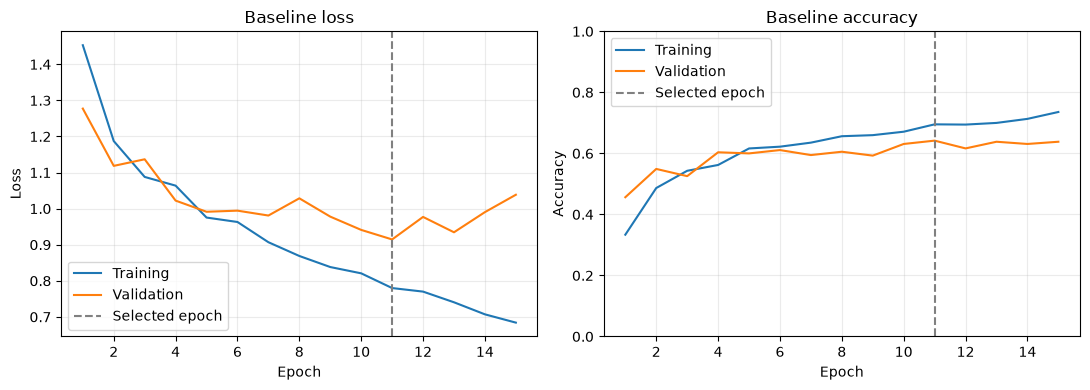

Saved baseline weights to outputs\flowers\baseline_cnn.pth; reload verified.
Saved validation results and the exact data split. Test evaluation remains pending.


In [7]:
flower_epochs = np.arange(1, FLOWER_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric in zip(axes, ["loss", "accuracy"]):
    ax.plot(flower_epochs, flower_baseline_history["train_" + metric], label="Training")
    ax.plot(flower_epochs, flower_baseline_history["val_" + metric], label="Validation")
    ax.axvline(flower_best_epoch, color="gray", linestyle="--", label="Selected epoch")
    ax.set(xlabel="Epoch", ylabel=metric.capitalize(), title="Baseline " + metric)
    ax.legend()
    ax.grid(alpha=0.25)
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

flower_output_dir = Path("outputs") / "flowers"
flower_output_dir.mkdir(parents=True, exist_ok=True)
flower_baseline_path = flower_output_dir / "baseline_cnn.pth"
torch.save({
    "state_dict": {k: v.detach().cpu() for k, v in flower_baseline.state_dict().items()},
    "architecture": "BaselineFlowerCNN",
    "class_names": flower_class_names,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "best_epoch": flower_best_epoch,
}, flower_baseline_path)

# Check that saving and reloading preserves the model's scores.
flower_checkpoint = torch.load(flower_baseline_path, map_location=flower_device, weights_only=True)
flower_reloaded_baseline = BaselineFlowerCNN(len(flower_class_names)).to(flower_device)
flower_reloaded_baseline.load_state_dict(flower_checkpoint["state_dict"])
flower_reloaded_baseline.eval()
with torch.no_grad():
    flower_check_batch = flower_batch_images.to(flower_device)
    torch.testing.assert_close(
        flower_baseline(flower_check_batch), flower_reloaded_baseline(flower_check_batch)
    )

flower_baseline_metrics = {
    "experiment": "course_baseline",
    "architecture": "BaselineFlowerCNN",
    "epochs": FLOWER_EPOCHS,
    "learning_rate": FLOWER_LEARNING_RATE,
    "batch_size": FLOWER_BATCH_SIZE,
    "image_size": FLOWER_IMAGE_SIZE,
    "seed": FLOWER_SEED,
    "device": str(flower_device),
    "pytorch_version": str(torch.__version__),
    "best_epoch": flower_best_epoch,
    "selected_validation_loss": flower_selected_val_loss,
    "selected_validation_accuracy": flower_selected_val_accuracy,
    "training_seconds": flower_training_seconds,
    "history": flower_baseline_history,
    "test_evaluated": False,
}
(flower_output_dir / "baseline_metrics.json").write_text(
    json.dumps(flower_baseline_metrics, indent=2), encoding="utf-8"
)
# Keep the exact split and class mapping for later experiments and visualisations.
flower_split_manifest = {
    "seed": FLOWER_SEED,
    "class_to_idx": flower_catalog.class_to_idx,
    "splits": {
        name: [Path(flower_catalog.samples[int(i)][0]).relative_to(flower_root).as_posix()
               for i in indices]
        for name, indices in [("train", flower_train_indices),
                              ("validation", flower_val_indices),
                              ("test", flower_test_indices)]
    },
}
(flower_output_dir / "split_manifest.json").write_text(
    json.dumps(flower_split_manifest, indent=2), encoding="utf-8"
)
print(f"Saved baseline weights to {flower_baseline_path}; reload verified.")
print("Saved validation results and the exact data split. Test evaluation remains pending.")

### Baseline findings

This run used the CPU and completed 15 epochs in about 1.6 minutes. The model has 286,117 trainable parameters.

| Measure | Result |
|---|---:|
| Epoch selected by lowest validation loss | 11 |
| Selected validation loss | 0.9146 |
| Selected validation accuracy | 64.18% |
| Final-epoch training accuracy | 73.57% |
| Final-epoch validation accuracy | 63.82% |

Training accuracy improved after epoch 11, but validation loss increased. This suggests overfitting and supports retaining the earlier checkpoint. A higher training score alone does not establish that a change helps on unseen images.

These are results from our run, not copied from the course notebook. Differences from the course results can arise from the device, software versions and numerical calculations. We will compare our later experiments with this baseline using the same split and evaluation method. The test set has not been evaluated.

**Next step:** add two convolutional blocks and one hidden linear layer with ReLU. Keep the initial comparison small and record whether the deeper model improves validation performance; greater depth does not guarantee improvement.